In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [2]:
df = pd.read_csv('flight_data.csv')
df.head(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [3]:
df.drop(['Unnamed: 0', 'flight','duration'], axis=1, inplace=True)
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,1,5955
...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,49,81585


In [4]:
df.drop(['days_left'], axis=1, inplace=True)
df.head(2)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,5953


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   airline           300153 non-null  object
 1   source_city       300153 non-null  object
 2   departure_time    300153 non-null  object
 3   stops             300153 non-null  object
 4   arrival_time      300153 non-null  object
 5   destination_city  300153 non-null  object
 6   class             300153 non-null  object
 7   price             300153 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 18.3+ MB


In [6]:
df.isnull().sum()

airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
price               0
dtype: int64

In [9]:
# Unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col} unique values: {df[col].unique()} ")

airline unique values: ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India'] 
source_city unique values: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai'] 
departure_time unique values: ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night'] 
stops unique values: ['zero' 'one' 'two_or_more'] 
arrival_time unique values: ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night'] 
destination_city unique values: ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi'] 
class unique values: ['Economy' 'Business'] 


Text(0.5, 0, 'Airline')

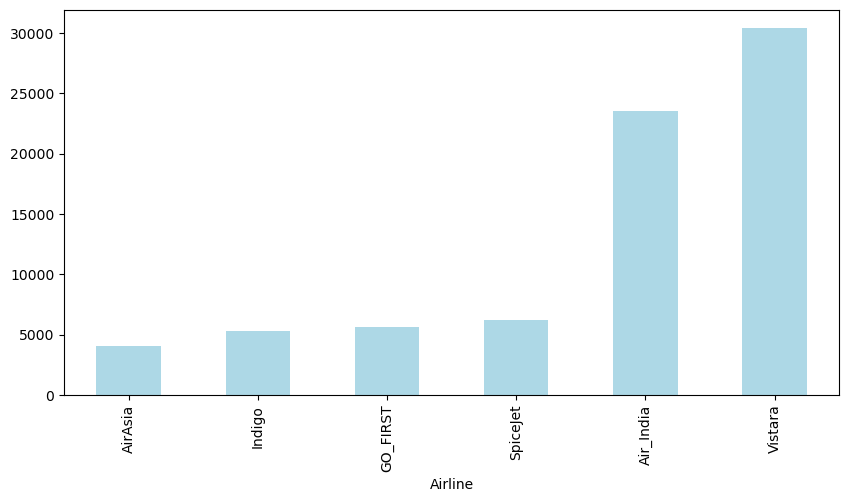

In [13]:
df.groupby('airline')['price'].mean().sort_values().plot(kind='bar', figsize=(10,5), color='lightblue')
plt.xlabel('Airline')

Text(0.5, 1.0, 'Average Flight Price by Class')

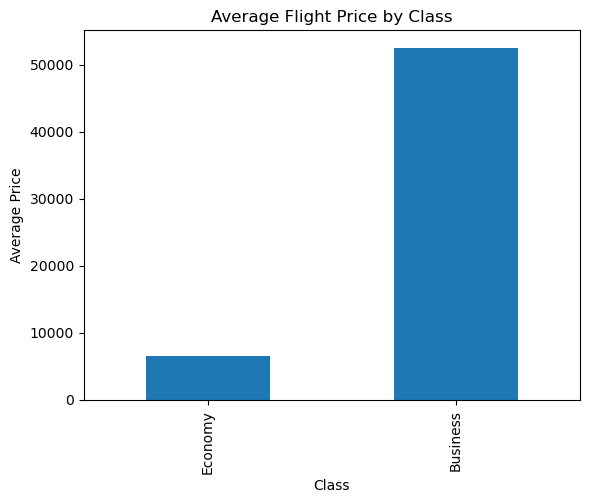

In [11]:
df.groupby('class')['price'].mean().sort_values().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Average Price')
plt.title('Average Flight Price by Class')

<Axes: xlabel='source_city'>

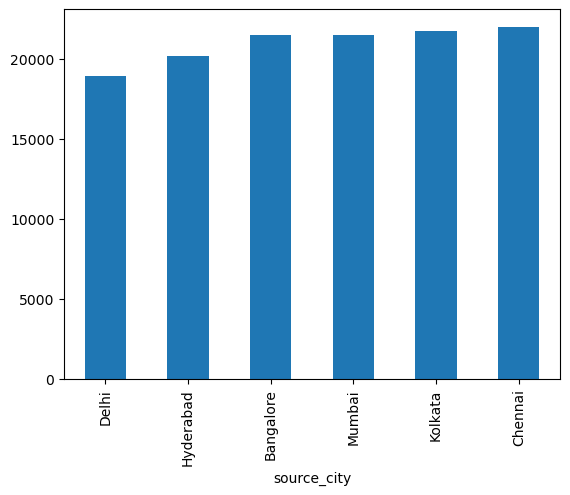

In [15]:
df.groupby('source_city')['price'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='destination_city'>

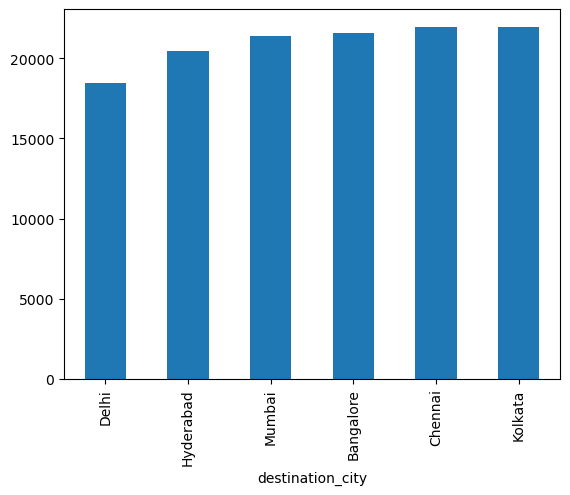

In [16]:
df.groupby('destination_city')['price'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='departure_time,arrival_time'>

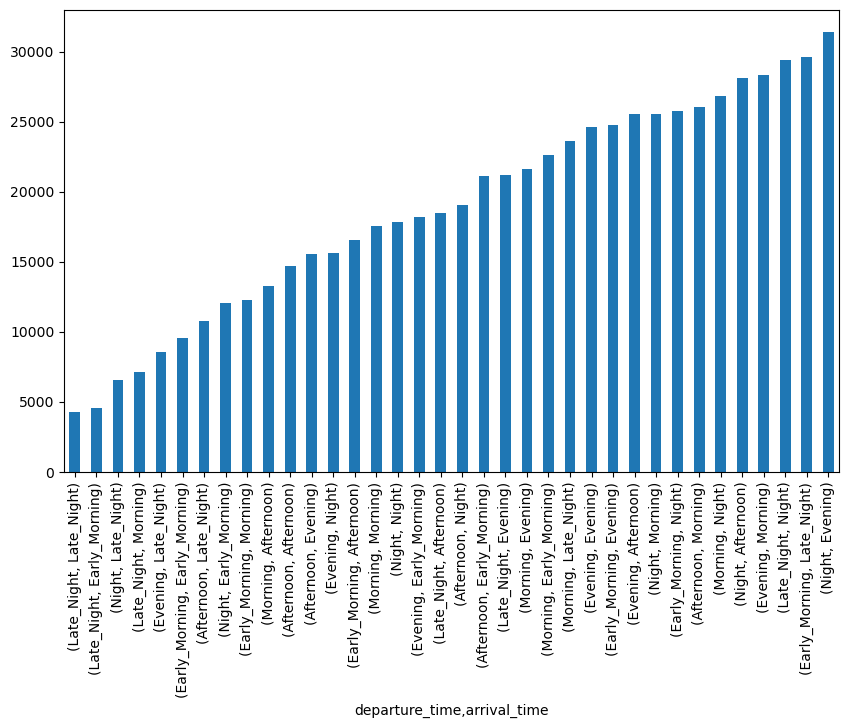

In [21]:
df.groupby(['departure_time','arrival_time'])['price'].mean().sort_values().plot(kind='bar', figsize=(10,6))

In [22]:
# Convert categorical variables to numeric using mapping
# airline unique values: ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India'] 
# source_city unique values: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai'] 
# departure_time unique values: ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night'] 
# stops unique values: ['zero' 'one' 'two_or_more'] 
# arrival_time unique values: ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night'] 
# destination_city unique values: ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi'] 
# class unique values: ['Economy' 'Business'] 
categorical_mappings = {
    'airline': {'SpiceJet': 0, 'AirAsia': 1, 'Vistara': 2, 'GO_FIRST': 3, 'Indigo': 4, 'Air_India': 5},
    'source_city': {'Delhi': 0, 'Mumbai': 1, 'Bangalore': 2, 'Kolkata': 3, 'Hyderabad': 4, 'Chennai': 5},
    'departure_time': {'Early_Morning': 0, 'Morning': 1, 'Afternoon': 2, 'Evening': 3, 'Night': 4, 'Late_Night': 5},
    'stops': {'zero': 0, 'one': 1, 'two_or_more': 2},
    'arrival_time': {'Early_Morning': 0, 'Morning': 1, 'Afternoon': 2, 'Evening': 3, 'Night': 4, 'Late_Night': 5},
    'destination_city': {'Mumbai': 0, 'Bangalore': 1, 'Kolkata': 2, 'Hyderabad': 3, 'Chennai': 4, 'Delhi': 5},
    'class': {'Economy': 0, 'Business': 1}
}
df.replace(categorical_mappings, inplace=True)
df.head(7)
    

C:\Users\kanch\AppData\Local\Temp\ipykernel_12060\4004545396.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(categorical_mappings, inplace=True)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,price
0,0,0,3,0,4,0,0,5953
1,0,0,0,0,1,0,0,5953
2,1,0,0,0,0,0,0,5956
3,2,0,1,0,2,0,0,5955
4,2,0,1,0,1,0,0,5955
5,2,0,1,0,2,0,0,5955
6,2,0,1,0,1,0,0,6060


In [23]:
# Splitting the data
X = df.drop('price', axis=1)
y = df['price']
X.shape, y.shape

((300153, 7), (300153,))

In [24]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((240122, 7), (60031, 7), (240122,), (60031,))

In [25]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")
# Example prediction
example_data = np.array([[2, 0, 3, 1, 4, 2, 0]])  # Example feature values
predicted_price = model.predict(example_data)
print(f"Predicted Flight Price: {predicted_price[0]}")


Mean Squared Error: 53253584.01103766
Root Mean Squared Error: 7297.505327921156
Mean Absolute Error: 4887.652587965251
R^2 Score: 0.8966917259009828
Predicted Flight Price: 7889.507726388531


c:\Users\kanch\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
# Save the model
import pickle
with open('flight_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)
